In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

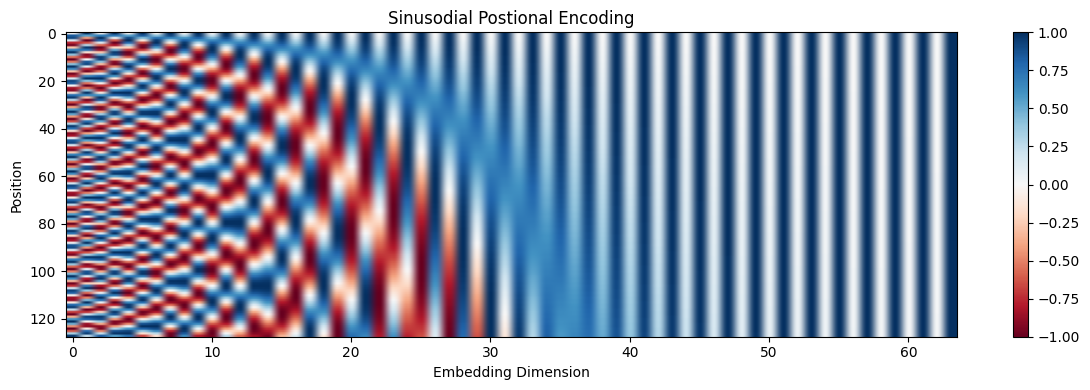

In [4]:
def positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)) / d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = positional_encoding(max_len = 128, d_model = 64)
plt.figure(figsize=(12, 4))
plt.imshow(pe.numpy(), cmap= 'RdBu', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Sinusodial Postional Encoding')
plt.colorbar()
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150)
plt.show()

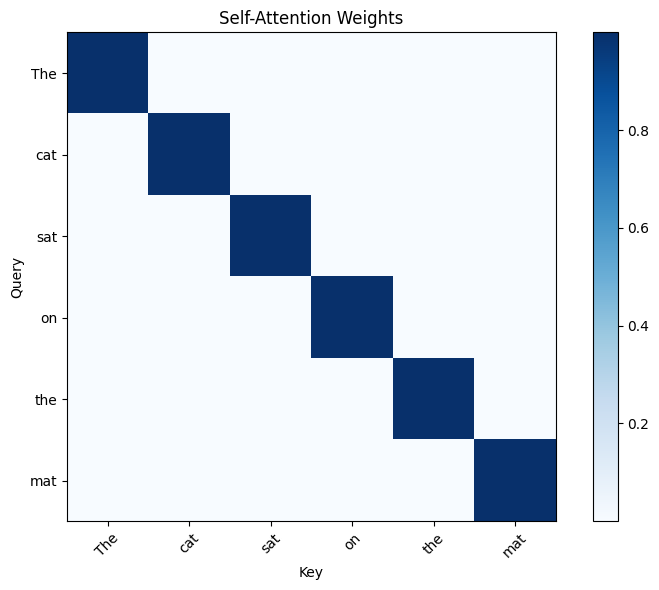

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

def visualize_attention(query, key, tokens):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1))
    scores = scores/math.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)

    plt.figure(figsize=(8,6))
    plt.imshow(weights.squeeze().detach().numpy(), cmap='Blues')
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel('Key')
    plt.ylabel('Query')
    plt.title('Self-Attention Weights')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig('attention_weights.png', dpi=150)
    plt.show()

tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']
seq_len = len(tokens)
d_model = 64
x = torch.randn(1, seq_len, d_model)
visualize_attention(x, x, tokens)

In [ ]:
import torch
import torch.nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len = 5000, dropout = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()*(-math.log(10000))/d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term) # (max_len, d_model)
        
        pe = pe.unsqueeze(0) # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.drop(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model, 
        self.num_heads = num_heads
        self.d_k = d_modle // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q: (batch, seq_len_q, d_k)
        K: (batch, seq_len_k, d_k)
        V: (batch, seq_len_k, d_v)
        mask: broadcastable to (batch, len_seq_q, len_seq_k)

        Return: 
            output: (batch, seq_len_q, d_v)
            weights: (batch, seq_len_q, seq_len_k)
        """
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-1, -2))
        scores = scores/math.sqrt(d_k) # (batch, seq_len_q, seq_len_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf')) # (batch, seq_len_q, seq_len_k)
        weights = F.softmax(scores, dim=-1) # (batch, seq_len_q, seq_len_k)
        context = torch.matmul(weights, V) # (batch, seq_len_q, d_v)
        return context, weights

    def foward(self, Q, K, V, mask = None):
        batch_size = Q.size(0)

        Q = self.W_Q(Q) # (batch, seq_len, d_model)
        K = self.W_K(K) # (batch, seq_len, d_model)
        V = self.W_V(V) # (batch, seq_len, d_model)

        # get differnt head
        # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, d_k) 
        # -> (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # context: (batch, num_heads, seq_len, d_v)
        # weights: (batch, num_heads, seq_len, seq_len), we do not use it here
        context, weights = scaled_dot_product_attention(Q, K, V, mask)

        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_O(context)
        return context

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()

    def forward(self, x):
        result = self.linear2(
            self.dropout(
                self.relu(self.linear1(x))
            )
        )
        return result

class TransformEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNor(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropput(dropout)

    def forward(x, mask=None):
        # sub_layer 1: self attention
        attn_out = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        # sub_layer 2: FeedfowardNetwork
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

class TransformEncoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TranformEncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x
        
        
        
        